<a href="https://colab.research.google.com/github/NatSy77/mlops_ai-projet6et8/blob/main/03_modeling_baseline_mlflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initiez-vous au MLOps (partie 1/2)

## Imports et configuration

In [3]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 15.5 MB/s eta 0:00:00


In [20]:
!pip install mlflow pyngrok

In [22]:
!pip install -q mlflow pyngrok

In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import mlflow
import mlflow.sklearn

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

### Configuration MLflow (pour Colab)

In [1]:
# Monter google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
mlflow.set_tracking_uri("file:///content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns")

mlflow.set_experiment("credit_scoring_baseline")

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/03 14:20:19 INFO mlflow.tracking.fluent: Experiment with name 'credit_scoring_baseline' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:///content/drive/MyDrive/Colab '
 'Notebooks/AI_projet_6&8/mlruns/743673765997684695'), creation_time=1775226019686, experiment_id='743673765997684695', last_update_time=1775226019686, lifecycle_stage='active', name='credit_scoring_baseline', tags={}, workspace='default'>

### Chargement des données

In [6]:
X = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/credit_scoring_data/processed/X_train.csv")
y = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/credit_scoring_data/processed/y_train.csv").values.ravel()

print(X.shape, y.shape)

(307511, 377) (307511,)


### Split train / validation
stratification (sinon biais énorme)

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

### Analyse rapide du déséquilibre

In [8]:
print("Taux classe positive :", y.mean())

Taux classe positive : 0.08072881945686496


### Fonction de coût métier

In [9]:
def business_cost(y_true, y_pred, fn_cost=10, fp_cost=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * fn_cost + fp * fp_cost


def business_cost_normalized(y_true, y_pred, fn_cost=10, fp_cost=1):
    return business_cost(y_true, y_pred, fn_cost, fp_cost) / len(y_true)

### Fonction d’évaluation complète

In [10]:
def evaluate_model(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    roc_auc = roc_auc_score(y_true, y_proba)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall_curve, precision_curve)

    cost = business_cost_normalized(y_true, y_pred)

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "business_cost": cost
    }

### Optimisation du seuil métier

TRÈS important pour OC

In [11]:
def find_best_threshold(y_true, y_proba, fn_cost=10, fp_cost=1):
    thresholds = np.arange(0.01, 0.99, 0.01)

    results = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        cost = business_cost_normalized(y_true, y_pred, fn_cost, fp_cost)
        results.append((t, cost))

    df = pd.DataFrame(results, columns=["threshold", "cost"])

    best_row = df.loc[df["cost"].idxmin()]

    return best_row["threshold"], df

### Pipeline Logistic Regression

#### 1. Identifier les colonnes numériques et catégorielles

In [15]:
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Nb colonnes numériques :", len(num_cols))
print("Nb colonnes catégorielles :", len(cat_cols))
print("Exemples colonnes catégorielles :", cat_cols[:10])

Nb colonnes numériques : 361
Nb colonnes catégorielles : 16
Exemples colonnes catégorielles : ['FLAG_OWN_REALTY', 'EMERGENCYSTATE_MODE', 'OCCUPATION_TYPE', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_TYPE_SUITE', 'HOUSETYPE_MODE', 'FLAG_OWN_CAR']


In [16]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

### Entraînement
Résultats baseline
- métrique	valeur	lecture
- ROC AUC	0.768	✔️ solide
- PR AUC	0.248	✔️ cohérent (baseline ~0.08)
- Recall	0.688	✔️ très bon (important métier)
- Precision	0.177	: faible mais attendu
- F1	0.28	ok
- Cost	0.51	: métrique clé
- Threshold	0.51 :	intéressant

Détectes bien les clients à risque (bon recall)
Refuses beaucoup de bons clients (precision faible)
→ normal avec FN > FP

In [17]:
with mlflow.start_run(run_name="logreg_baseline"):

    # Entraînement
    pipeline.fit(X_train, y_train)

    # Probabilités
    y_proba = pipeline.predict_proba(X_val)[:, 1]

    # Seuil optimal
    best_threshold, threshold_df = find_best_threshold(y_val, y_proba)

    # Évaluation avec seuil optimisé
    metrics = evaluate_model(y_val, y_proba, best_threshold)

    # Logging MLflow
    mlflow.log_param("model", "logistic_regression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("fn_cost", 10)
    mlflow.log_param("fp_cost", 1)
    mlflow.log_param("threshold", best_threshold)

    for key, value in metrics.items():
        mlflow.log_metric(key, value)

    # Sauvegarde modèle
    mlflow.sklearn.log_model(pipeline, "model")

    print("Seuil optimal :", best_threshold)
    print(metrics)

2026/04/03 14:42:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 14:42:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Seuil optimal : 0.51
{'roc_auc': np.float64(0.7684144631651102), 'pr_auc': np.float64(0.24848842715869918), 'precision': 0.17675644936152612, 'recall': 0.6886203423967775, 'f1': 0.28130656573967416, 'business_cost': np.float64(0.510284051184495)}


### Courbe coût vs seuil (artifact MLflow)

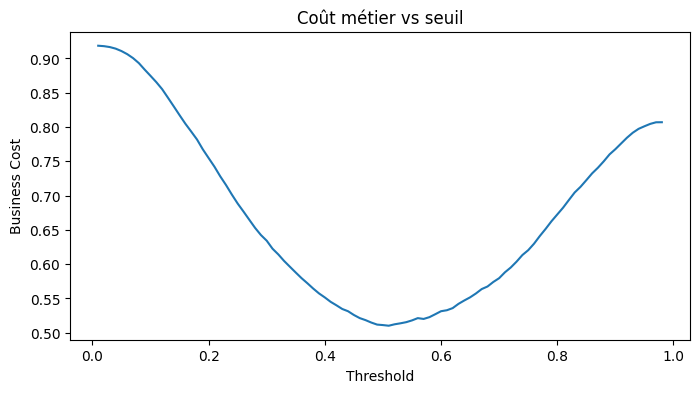

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["cost"])
plt.xlabel("Threshold")
plt.ylabel("Business Cost")
plt.title("Coût métier vs seuil")

plt.savefig("cost_vs_threshold.png")
mlflow.log_artifact("cost_vs_threshold.png")

plt.show()

### Matrice de confusion

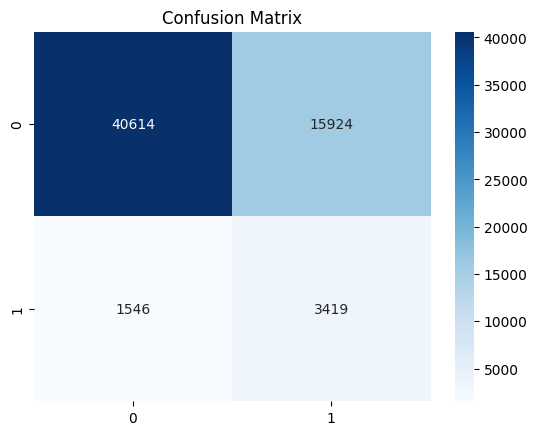

In [19]:
y_pred = (y_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_val, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")
mlflow.log_artifact("confusion_matrix.png")

plt.show()

### + MLflow

In [23]:
import os
from pyngrok import ngrok

os.makedirs("/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlflow_ui", exist_ok=True)

In [24]:
!mlflow ui --backend-store-uri "file:///content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns" --port 5000 &

Registry store URI not provided. Using backend store URI.
/usr/local/lib/python3.12/dist-packages/mlflow/server/handlers.py:343: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, artifact_uri)
/usr/local/lib/python3.12/dist-packages/mlflow/server/handlers.py:378: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri)
[MLflow] Security middleware enabled with default settings (localhost-only). T

In [27]:
print("Tracking URI:", mlflow.get_tracking_uri())
!ls "/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns"

Tracking URI: file:///content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns
0  743673765997684695  models


In [28]:
MLFLOW_TRACKING_URI = "file:///content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns"

!mlflow ui --backend-store-uri "$MLFLOW_TRACKING_URI" --port 5000 &

Registry store URI not provided. Using backend store URI.
/usr/local/lib/python3.12/dist-packages/mlflow/server/handlers.py:343: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, artifact_uri)
/usr/local/lib/python3.12/dist-packages/mlflow/server/handlers.py:378: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri)
[MLflow] Security middleware enabled with default settings (localhost-only). T

In [29]:
from pyngrok import ngrok
public_url = ngrok.connect(5000)
print(public_url)

ERROR:pyngrok.process.ngrok:t=2026-04-03T15:19:16+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-03T15:19:16+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [30]:
!cat "/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns/743673765997684695/meta.yaml"

artifact_location: file:///content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns/743673765997684695
creation_time: 1775226019686
experiment_id: '743673765997684695'
last_update_time: 1775226019686
lifecycle_stage: active
name: credit_scoring_baseline
workspace: default


In [31]:
!find "/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns/743673765997684695" -maxdepth 2 -type f | head -30

/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns/743673765997684695/meta.yaml
/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns/743673765997684695/509c1a81f4ca4b3cb4d4302982be9e48/meta.yaml
/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns/743673765997684695/d197e6dd9b9040dc80e64b8782f969bc/meta.yaml
/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns/743673765997684695/6e5a797f5a8743af9f37684f6d7daa2b/meta.yaml


#### Supprimer les serveurs MLflow/ngrok en cours

In [35]:
!pkill -f "mlflow"
!pkill -f "ngrok"

#### Relancer MLflow

In [33]:
MLRUNS_PATH = "/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns"

!mlflow server \
  --backend-store-uri "$MLRUNS_PATH" \
  --default-artifact-root "$MLRUNS_PATH" \
  --host 0.0.0.0 \
  --port 5000 &

Registry store URI not provided. Using backend store URI.
/usr/local/lib/python3.12/dist-packages/mlflow/server/handlers.py:343: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, artifact_uri)
/usr/local/lib/python3.12/dist-packages/mlflow/server/handlers.py:378: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri)
[MLflow] Security middleware enabled with default settings (localhost-only). T

In [34]:
from pyngrok import ngrok

ngrok.kill()
public_url = ngrok.connect(5000)
print(public_url)

ERROR:pyngrok.process.ngrok:t=2026-04-03T15:39:32+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-03T15:39:32+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-03T15:39:32+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.